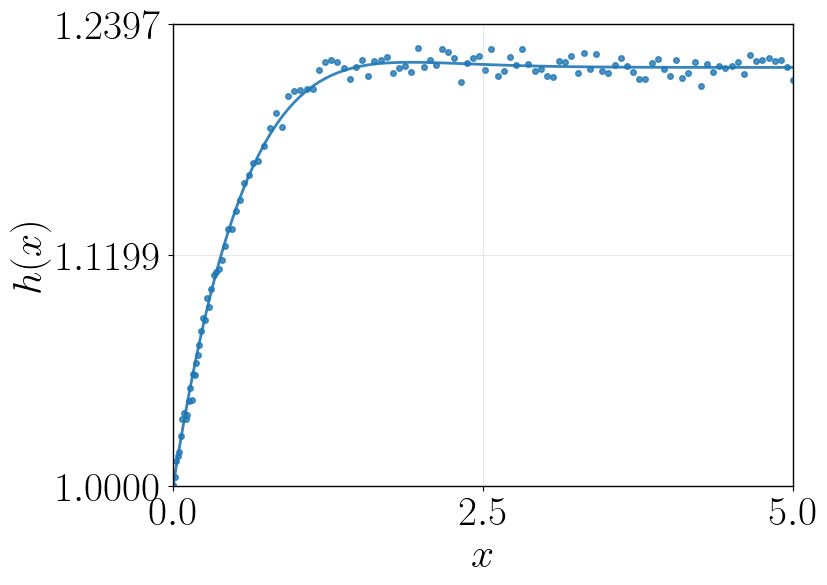

curve4_y GPR on (lambda, beta, log10 epsilon), 160 curves: 0.348**2 * RBF(length_scale=[0.38, 0.601, 0.272])
MLE fit: lambda = 4.525, beta = 0.4962, epsilon = 0.2569; sigma_MLE = RMS(delta) = 5.864e-05, max|delta(x)| = 0.0001536


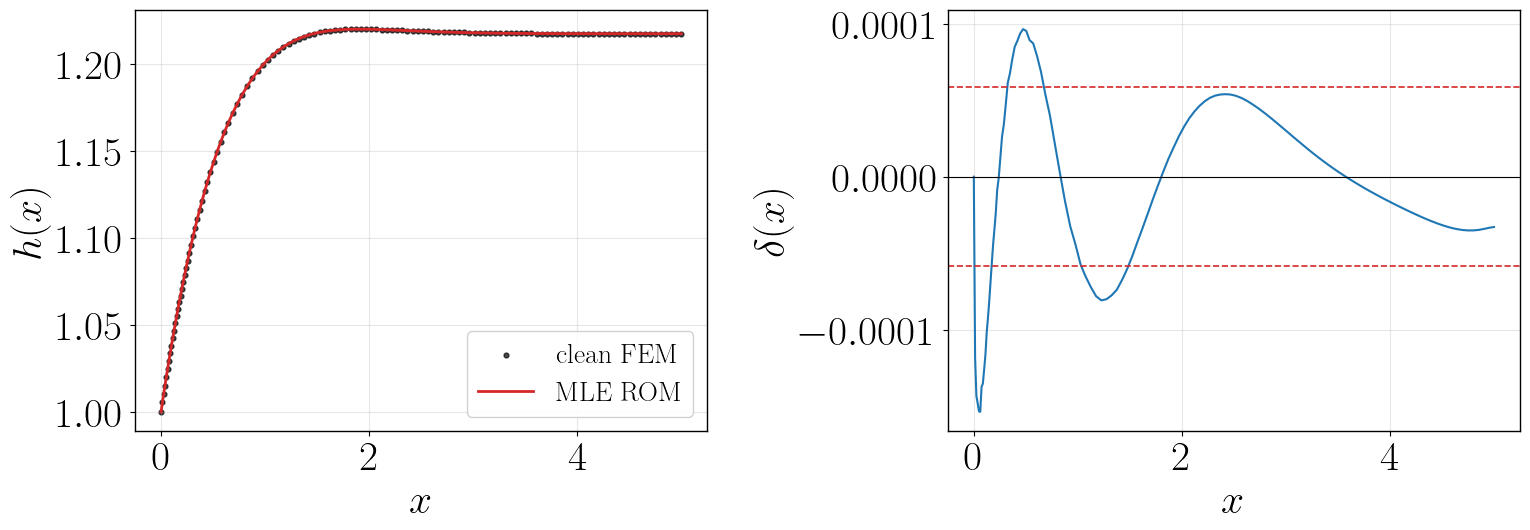

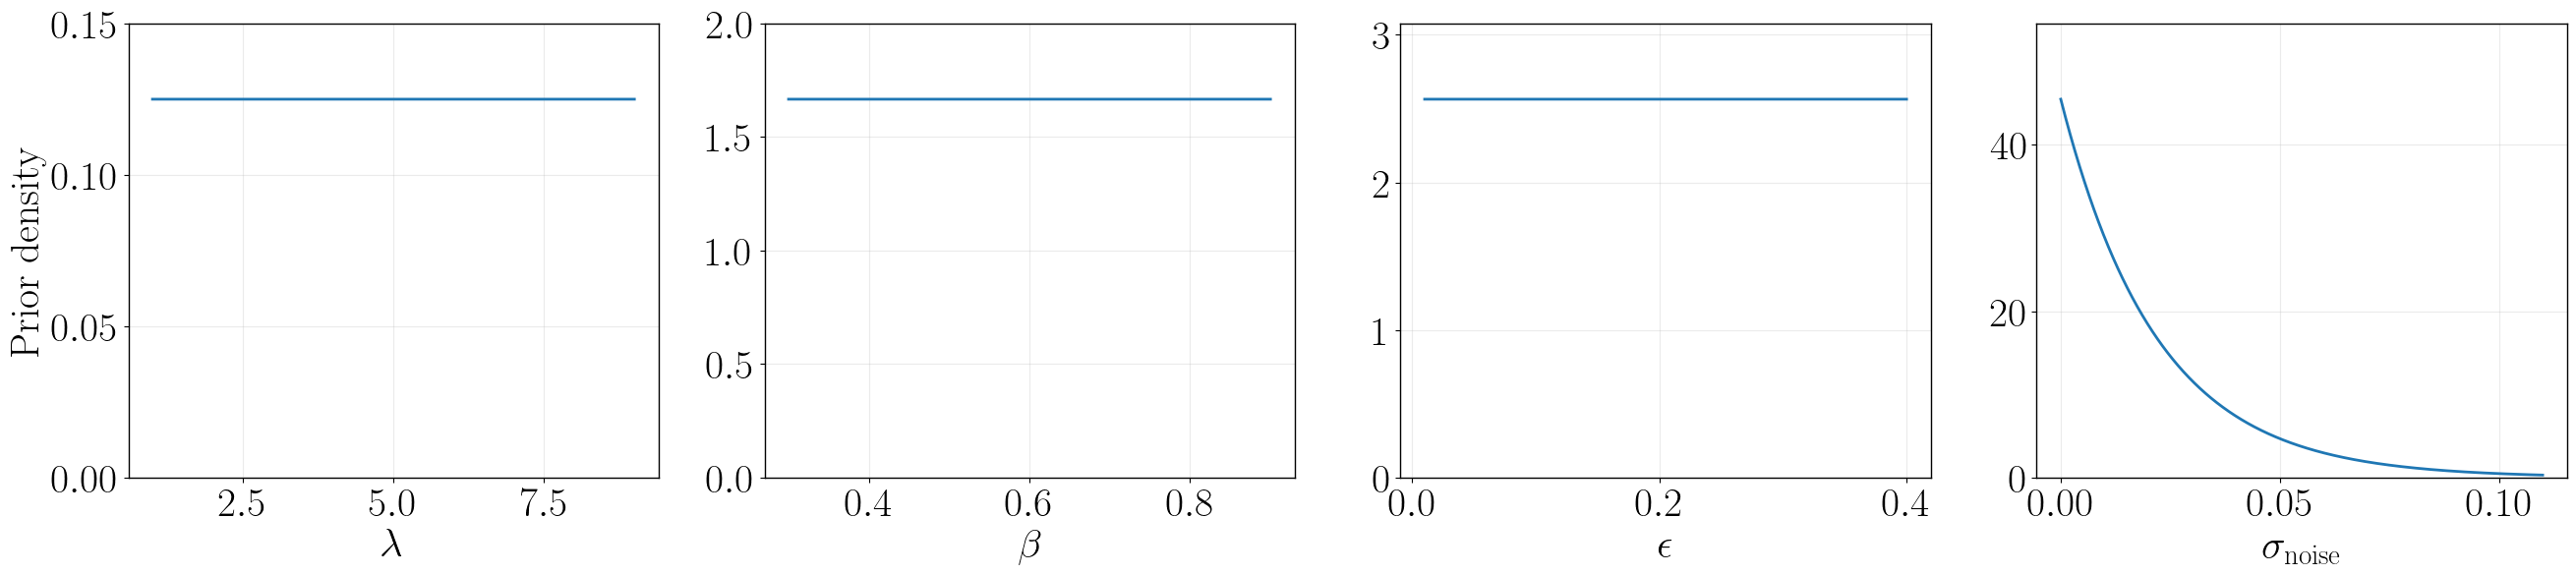

Initial walkers (first 20 of 20, physical space):
          lambda          beta       epsilon   sigma_noise
          6.0957       0.46187       0.02598      0.013764
          1.1322       0.78796       0.36597      0.063297
          5.8531        0.7377       0.22201     0.0092787
          8.4806       0.78951      0.011068      0.024072
          7.8592       0.32015       0.29457      0.013933
          2.4052       0.81791       0.22117      0.013293
          3.3977       0.55361      0.021045      0.026737
          1.9943       0.70237        0.2624      0.015683
          5.9231       0.53021       0.39891     0.0015093
          8.8467       0.71133       0.26368     0.0034665
          6.5076       0.53335      0.062688      0.024436
          6.7719       0.61521       0.13099      0.045502
          4.8867       0.83369       0.37428      0.014038
          3.8624       0.64292       0.13553      0.015541
          5.7544       0.50275       0.16273     0.0017235
      

100%|██████████| 1000/1000 [00:02<00:00, 483.15it/s]


Walkers restarted after warm-up (first 20 of 20, physical space):
          lambda          beta       epsilon   sigma_noise
          6.1309       0.47914       0.36274     0.0040729
          5.9282        0.4822        0.3753     0.0041753
          5.8767        0.4721       0.33882     0.0040652
          5.3797        0.4786       0.32703     0.0039711
          5.9256       0.47799       0.35841     0.0041869
           6.053       0.48844       0.33803     0.0041029
          6.3693       0.48054       0.33654     0.0039481
          5.9521       0.48132       0.33151     0.0040347
          6.0436       0.48331       0.35468     0.0041033
           5.892       0.47915       0.36546     0.0042417
          5.7065       0.48935       0.37609     0.0041551
          6.1735       0.47801       0.37821     0.0042985
          6.6447       0.48812       0.35738     0.0039132
           6.091       0.48403       0.32623     0.0041082
          6.2242       0.48428        0.3282     

100%|██████████| 10000/10000 [00:22<00:00, 452.13it/s]


Parameter              Mean         Std      Rhat     90% CI Low    90% CI High
lambda           5.8043e+00  6.0747e-01     1.004     4.7414e+00     6.7243e+00
beta             4.8171e-01  1.2282e-02     1.002     4.6222e-01     5.0281e-01
epsilon          3.3316e-01  3.7529e-02     1.004     2.6819e-01     3.9081e-01
sigma_noise      4.1933e-03  2.5835e-04     1.002     3.7870e-03     4.6378e-03
saved results to C:\Users\paraj\Documents\bayesian-die-swell-main\results\bias_false_infer-0.2_giesekus_lam_5_beta_0p5_alpha_0p2.txt
steady shear (compute_n1_ptt_function) at gammadot_w = 0.8 (4 U_avg / R)
E[N1] (ptt) = 0.489064 +/- 0.0328909  (90% CI [0.441333, 0.542975], n=500)
E[S_R] = 0.913773 +/- 0.0388333  (90% CI [0.854075, 0.973097])  tau_w = 0.53479
true N1 (FEM, curve5_0002.txt) = 0.566714, true S_R = N1_true / tau_w = 1.01478, true gammadot_w = 0.847013
saved results to C:\Users\paraj\Documents\bayesian-die-swell-main\results\bias_false_infer-0.2_giesekus_lam_5_beta_0p5_alpha_0p2.tx

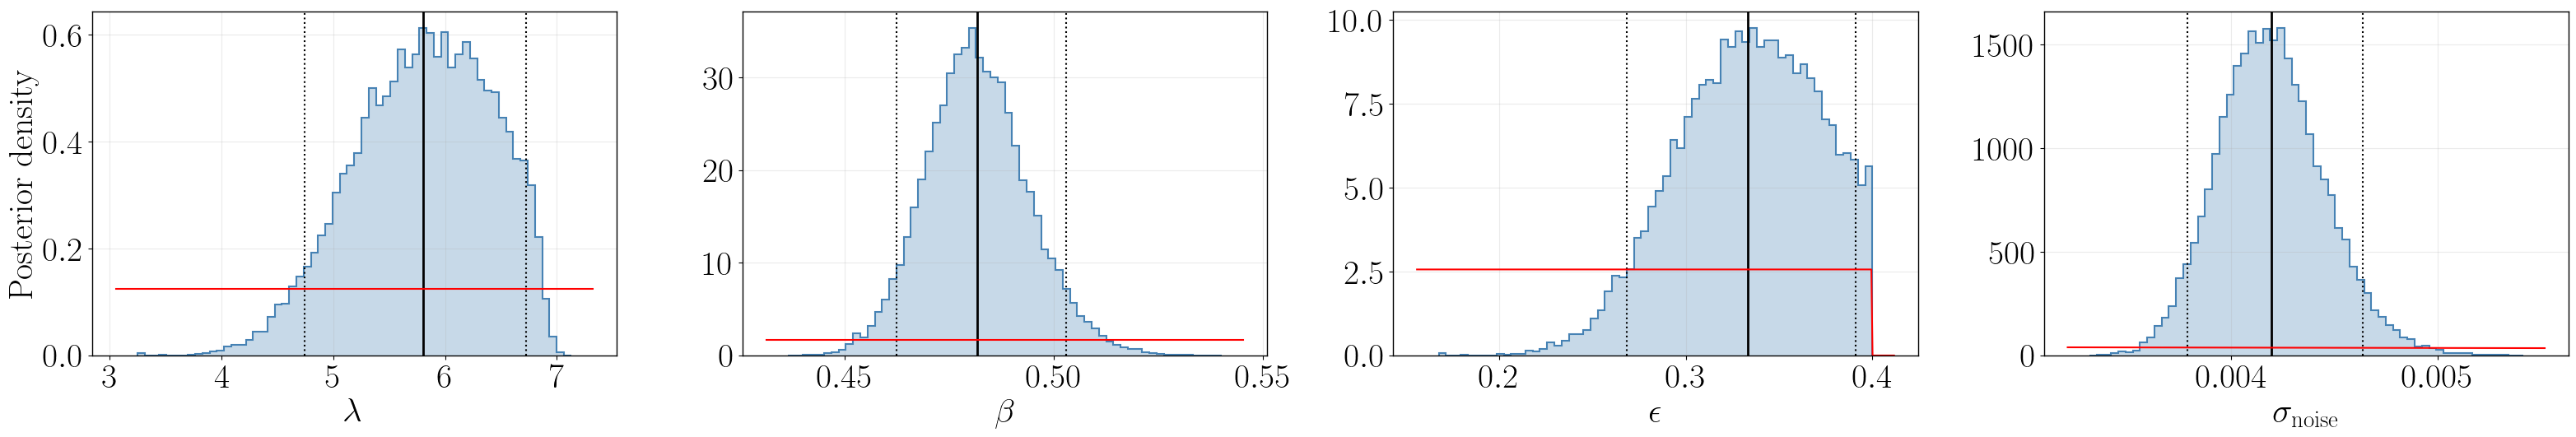

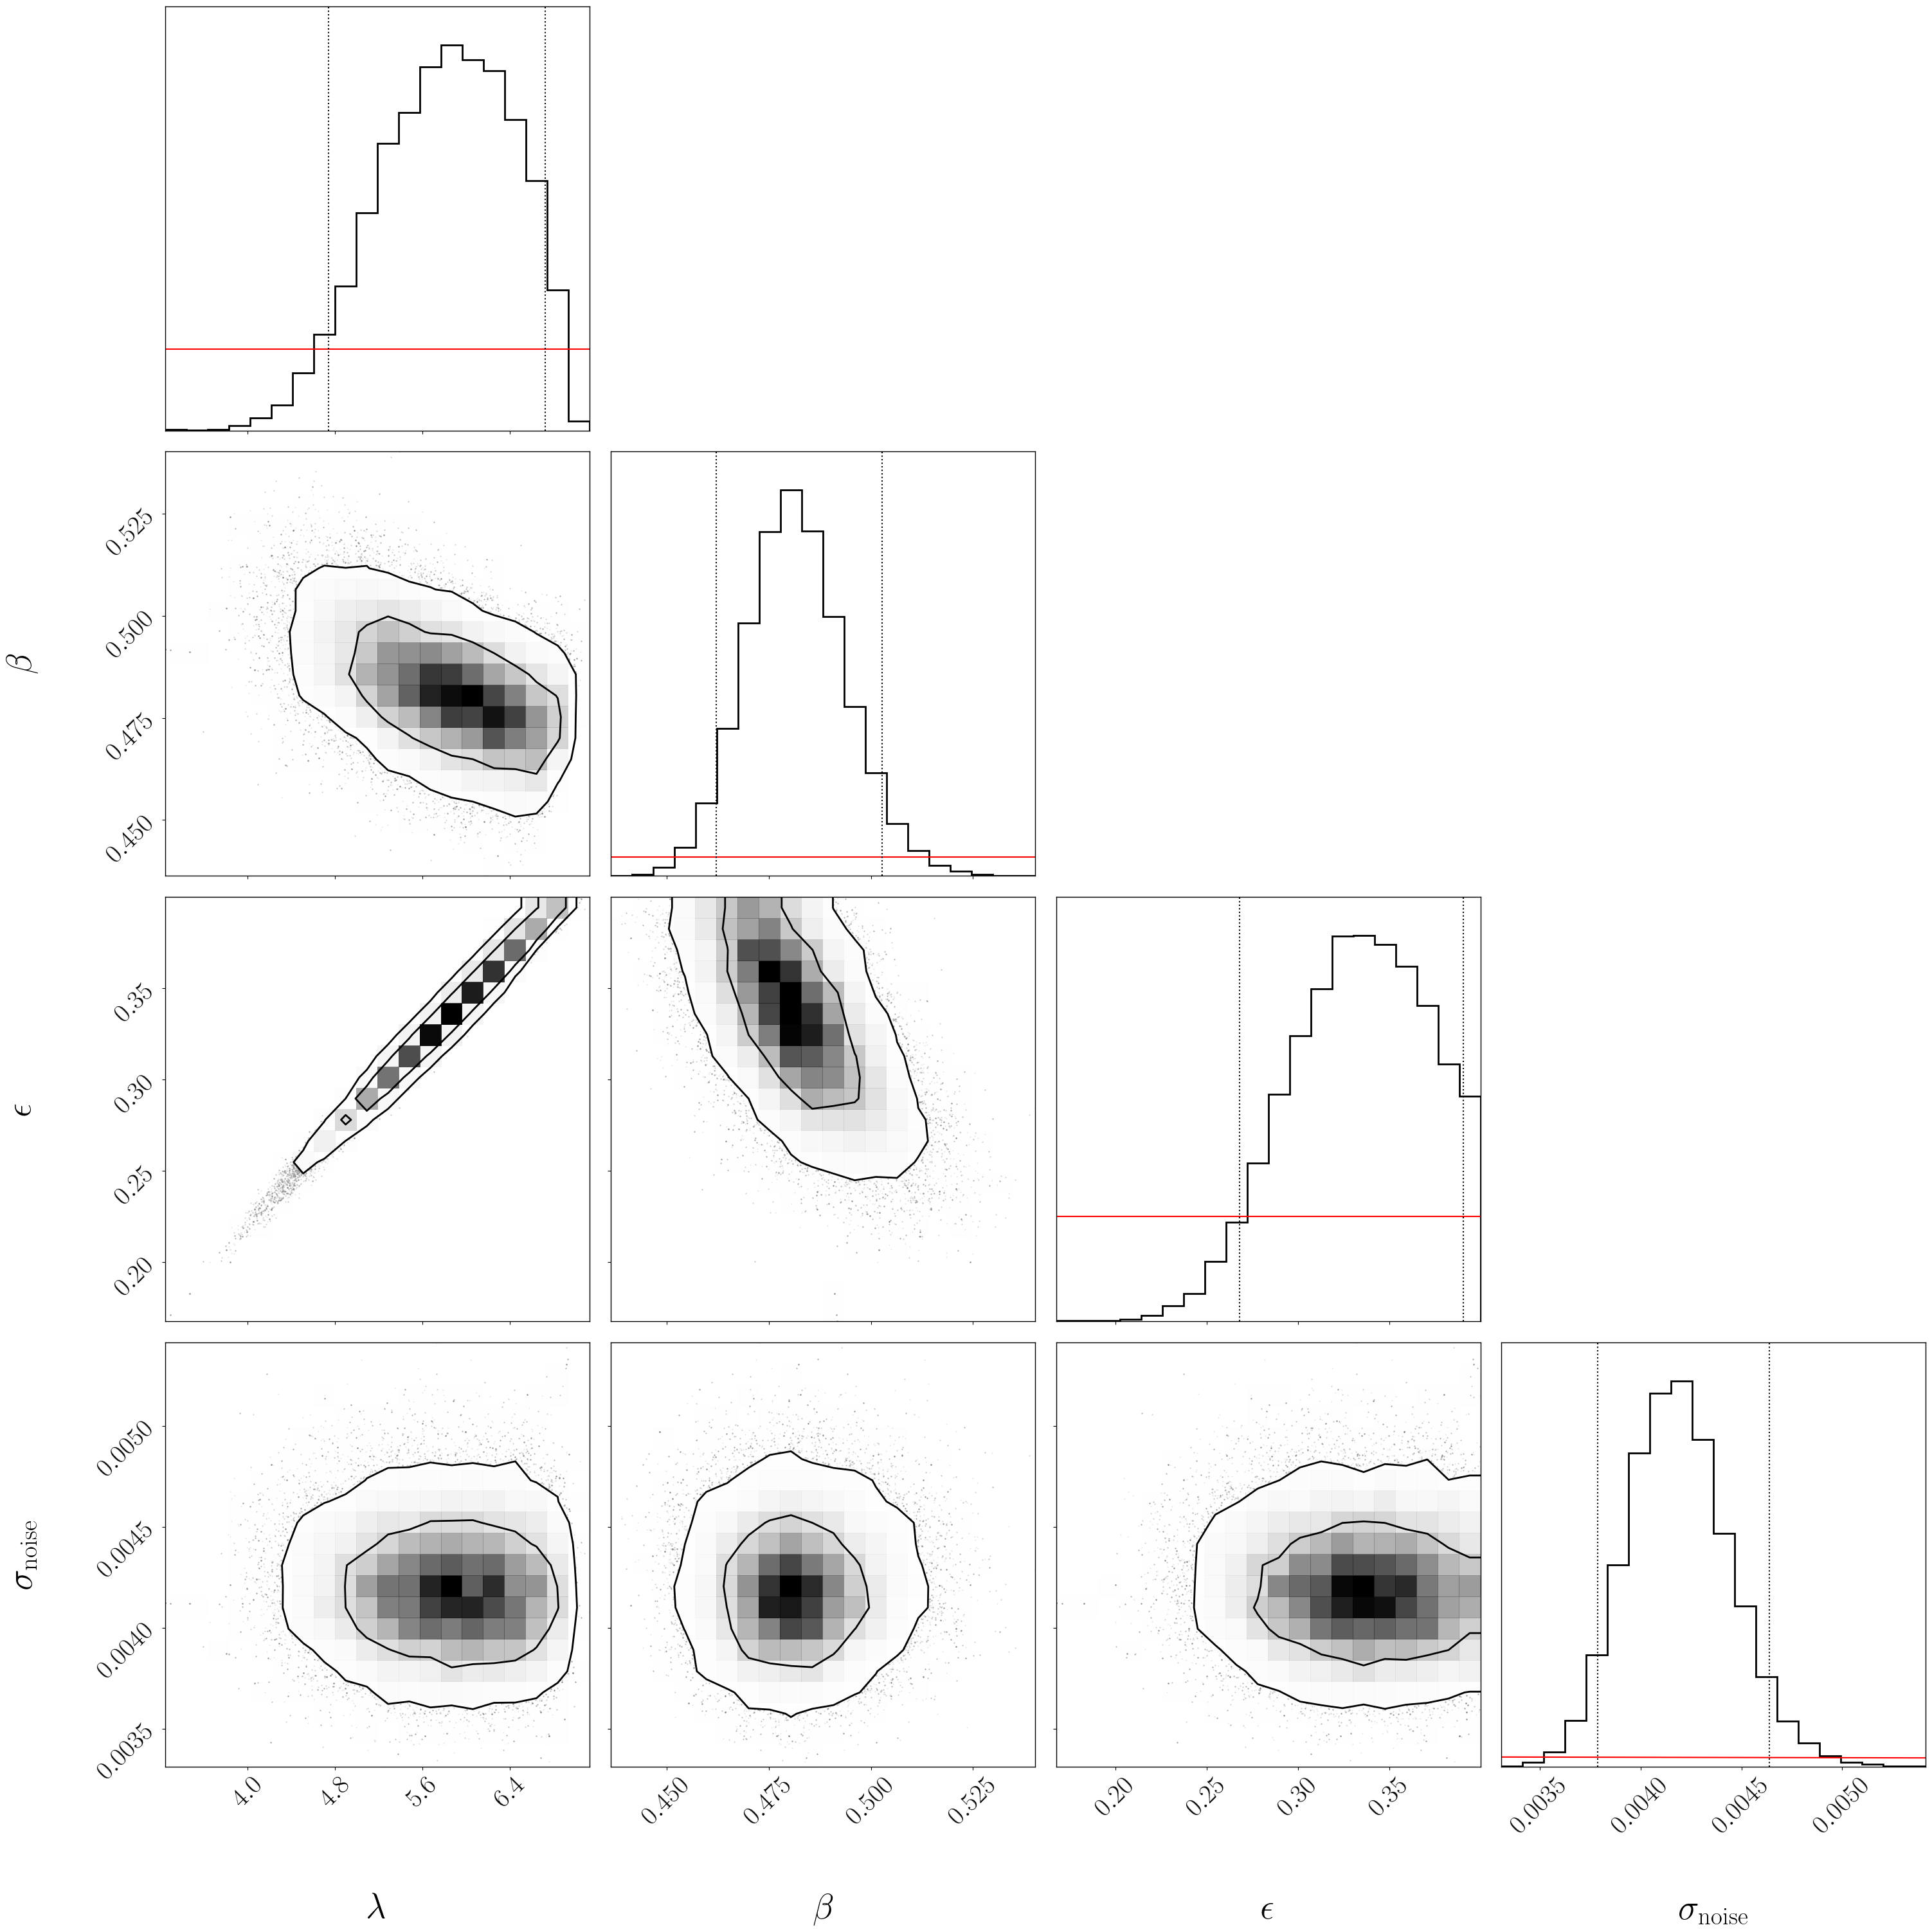

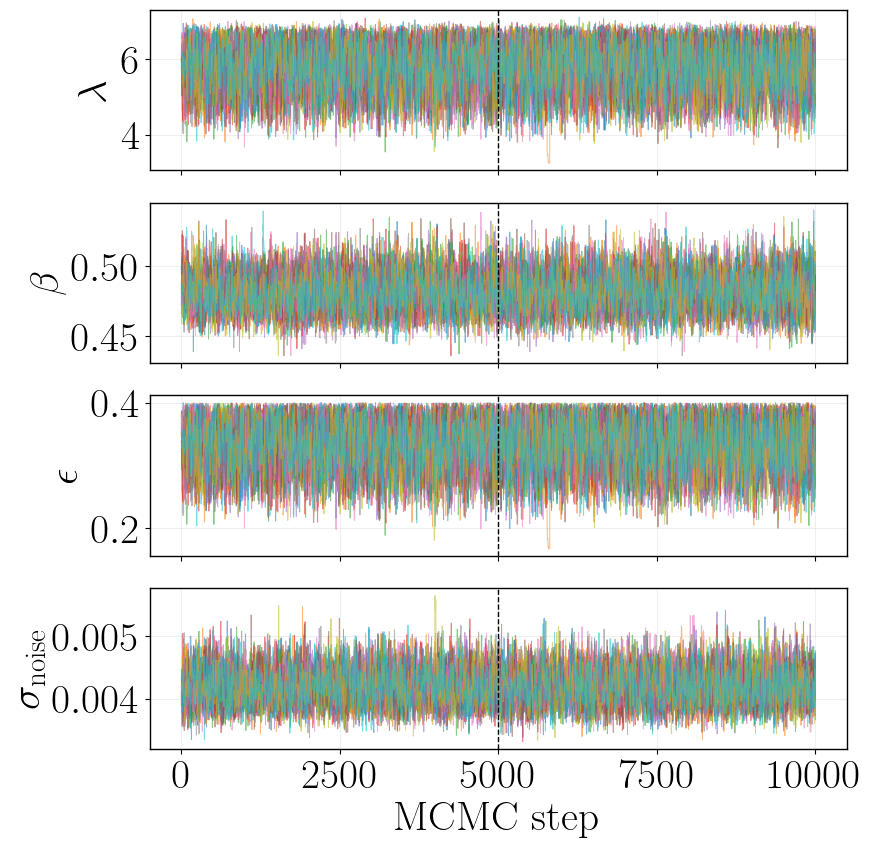


Posterior predictive (90% band)
  coverage=92.7%  rms_z=0.97  max|z|=2.49  mean_z=-0.01


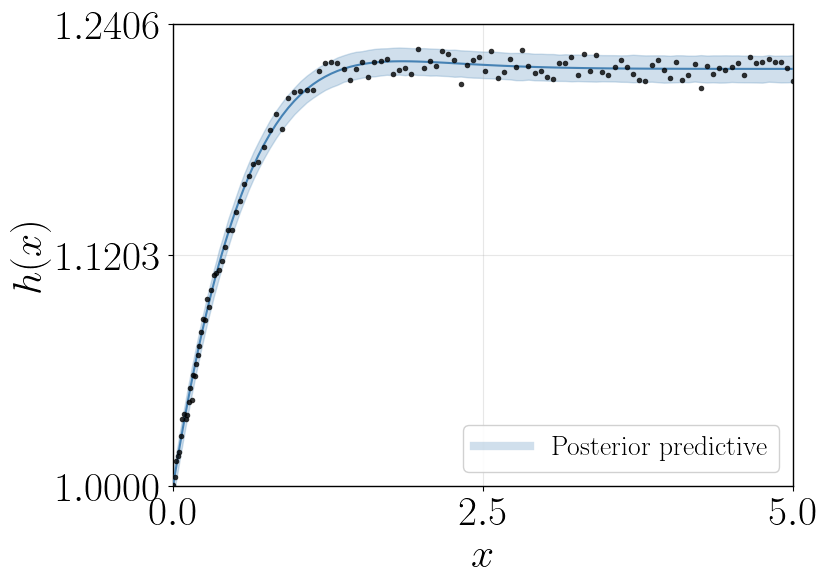


Posterior predictive (90% band)
  coverage=92.7%  rms_z=0.97  max|z|=2.49  mean_z=-0.01
saved plots to C:\Users\paraj\Documents\bayesian-die-swell-main\results\bias_false_l_bias_none_unconstrained_infer-0.2_giesekus_lam_5_beta_0p5_alpha_0p2


WindowsPath('C:/Users/paraj/Documents/bayesian-die-swell-main/results/bias_false_l_bias_none_unconstrained_infer-0.2_giesekus_lam_5_beta_0p5_alpha_0p2')

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="ptt",
    parametrize = False,   
    train_data_rels=["datas/ptt-rom-m3/train-0.2"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (1.0, 9.0),
    beta_bounds = (0.3, 0.9),
    alpha_bounds = (0.01, 0.4),
    sigma_noise_percent=2.0,
    thin=1,
    sigma_bias=None,
    constrained_model_error=True,
    theta = [5.0, 0.5, 0.2],
    l_bias = "infer", U_avg = 0.2, seed = 0, rabinowitsch_correction=False)

model.load_data(filename="datas/oldroyd-rom-m3/infer-0.2/giesekus_lam_5_beta_0p5_alpha_0p2/curve4_y.txt")
model.plot_data()
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=20, nsteps=10000, burn_fraction=0.5)
model.compute_N1()
model.plot_posterior()
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()
model.save_plots()